<a href="https://colab.research.google.com/github/Cromyz/project_dermai_assist/blob/LF_datacheck/all_data_EffNetB2_finetune_improved_021225.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Data set: Skin Cancer MNIST: HAM10000

This is an analysis of a large collection of multi-source dermatoscopic images of pigmented lesions

The final dataset consists of 10015 dermatoscopic images.

Cases include a representative collection of all important diagnostic categories in the realm of pigmented lesions:
- **akiec**: Actinic keratoses and intraepithelial carcinoma / Bowen's disease
- **bcc**: Basal cell carcinoma  
- **bkl**: benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses)
- **df**: Dermatofibroma (df),
- **mel**: Melanoma (mel),
- **nv**: Melanocytic nevi (nv) and
- **vasc**: Vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage, vasc).

<h2> 1. Setup, mounting Drive & imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# =========================
# Imports
# =========================
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from keras.applications.efficientnet import EfficientNetB2, preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)

Mounted at /content/drive
TensorFlow version: 2.19.0


<h2> 2. Load HAM10000 metadata & build image paths

In [ ]:
# =========================
# Paths to metadata & image folders
# =========================
data_dir = "/content/drive/MyDrive/Data"

metadata_path = f"{data_dir}/HAM10000_metadata.csv"
img_dir_1 = f"{data_dir}/HAM10000_images_part_1"
img_dir_2 = f"{data_dir}/HAM10000_images_part_2"

# Load metadata
df = pd.read_csv(metadata_path)
print("Metadata shape:", df.shape)

# Ensure unique images
df = df.drop_duplicates(subset="image_id").reset_index(drop=True)

def find_image_path(image_id):
    filename = f"{image_id}.jpg"
    path1 = os.path.join(img_dir_1, filename)
    path2 = os.path.join(img_dir_2, filename)

    if os.path.exists(path1):
        return path1
    if os.path.exists(path2):
        return path2

    print(f"⚠️ Image not found: {filename}")
    return None

df["img_path"] = df["image_id"].apply(find_image_path)
missing_paths = df["img_path"].isna().sum()
print("Missing image paths:", missing_paths)
assert missing_paths == 0, "Some images in metadata were not found in image folders!"

df.head()


Metadata shape: (10015, 7)
Missing image paths: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/Data/HAM10000_images_pa...


<h2> 3. Clean metadata (age, sex, localization) & encode labels

In [ ]:
# =========================
# Basic missing-value inspection
# =========================
print("\nMissing values before cleaning:")
print(df[["age", "sex", "localization"]].isna().sum())

# Also check 'unknown' tokens
print("Number of 'unknown' in sex:", (df['sex'] == 'unknown').sum())
print("Number of 'unknown' in localization:", (df['localization'] == 'unknown').sum())

# =========================
# Drop rows where ALL 3 are unknown/missing (no metadata at all)
# =========================
condition_all_three = (
    df["age"].isna() &
    (df["sex"] == "unknown") &
    (df["localization"] == "unknown")
)

rows_to_remove = condition_all_three.sum()
print("Rows removed (age NaN & sex unknown & localization unknown):", rows_to_remove)

df_clean = df[~condition_all_three].reset_index(drop=True)

# =========================
# Impute / clean metadata
# =========================
# 1. Age: fill NaN with median (skewed distribution)
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# 2. Sex: replace 'unknown' with dedicated category 'unk'
df_clean["sex"] = df_clean["sex"].replace("unknown", "unk")

# 3. Localization: replace 'unknown' with 'unk'
df_clean["localization"] = df_clean["localization"].replace("unknown", "unk")

print("\nMissing values after cleaning:")
print(df_clean[["age", "sex", "localization"]].isna().sum())

# =========================
# Label encoding: dx → integer label
# =========================
class_names = sorted(df_clean["dx"].unique())
class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {idx: name for name, idx in class_to_index.items()}

df_clean["label"] = df_clean["dx"].map(class_to_index)
num_classes = len(class_names)

print("\nClasses (dx) and their indices:")
print(class_to_index)
print("Number of classes:", num_classes)

df_clean[["image_id", "dx", "label"]].head()


Missing values before cleaning:
age             57
sex              0
localization     0
dtype: int64
Number of 'unknown' in sex: 57
Number of 'unknown' in localization: 234
Rows removed (age NaN & sex unknown & localization unknown): 47

Missing values after cleaning:
age             0
sex             0
localization    0
dtype: int64

Classes (dx) and their indices:
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Number of classes: 7


,image_id,dx,label
0,ISIC_0027419,bkl,2
1,ISIC_0025030,bkl,2
2,ISIC_0026769,bkl,2
3,ISIC_0025661,bkl,2
4,ISIC_0031633,bkl,2


<h2> 4. Train/validation split & metadata preprocessing

	•	Use 80% train / 20% validation, stratified by label.
	•	Standardize age.
	•	One-hot encode sex and localization.

In [ ]:
# =========================
# Train / validation split
# =========================
train_df, val_df = train_test_split(
    df_clean[["img_path", "label", "age", "sex", "localization"]],
    test_size=0.2,
    random_state=42,
    stratify=df_clean["label"]
)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

# =========================
# Metadata preprocessing with ColumnTransformer
# =========================
meta_features = ["age", "sex", "localization"]

meta_preprocessor = ColumnTransformer([
    ("scale_age", StandardScaler(), ["age"]),
    ("encode_cat", OneHotEncoder(sparse_output=False), ["sex", "localization"])
])

# Fit ONLY on train data
meta_preprocessor.fit(train_df[meta_features])

train_meta = meta_preprocessor.transform(train_df[meta_features])
val_meta   = meta_preprocessor.transform(val_df[meta_features])

train_meta = train_meta.astype("float32")
val_meta   = val_meta.astype("float32")

print("Train_meta shape:", train_meta.shape)
print("Val_meta shape:", val_meta.shape)

Train samples: 7974
Val samples: 1994
Train_meta shape: (7974, 19)
Val_meta shape: (1994, 19)


<h2> 5. Build tf.data.Dataset for (image, metadata) → label

> We’ll preprocess images for EfficientNetB2 in the dataset pipeline.




In [ ]:
# =========================
# tf.data pipeline (Colab-safe)
# =========================
IMG_SIZE = 224       # safer than 260 for free GPU, still good for EfficientNetB2
BATCH_SIZE = 16      # safe on T4/L4
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

def make_dataset(df, meta, shuffle=False):
    """
    Creates a tf.data.Dataset yielding:
        ((image_tensor, meta_tensor), label)
    """
    paths = df["img_path"].values
    labels = df["label"].values.astype("int32")
    meta = meta.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((paths, meta, labels))

    def load(path, meta_vec, label):
        # Load and decode image
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32)  # [0,255]

        # EfficientNet preprocessing (scales to correct range)
        img = preprocess_input(img)

        return (img, meta_vec), label

    ds = ds.map(load, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=2048, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, train_meta, shuffle=True)
val_ds   = make_dataset(val_df,   val_meta,   shuffle=False)


<h2> 6. Loss functions (label smoothing + focal loss)

In [ ]:
# =========================
# Loss functions
# =========================

def sparse_ce_with_smoothing(y_true, y_pred, smoothing=0.1):
    """
    Sparse categorical crossentropy with label smoothing.
    Converts sparse y_true to one-hot internally.
    """
    # Ensure shape (batch,)
    y_true = tf.reshape(y_true, (-1,))
    y_true = tf.cast(y_true, tf.int32)

    num_classes = tf.shape(y_pred)[-1]
    y_true_onehot = tf.one_hot(y_true, num_classes)

    pos = 1.0 - smoothing
    neg = smoothing / tf.cast(num_classes - 1, tf.float32)

    y_smooth = y_true_onehot * pos + (1.0 - y_true_onehot) * neg

    return tf.keras.losses.categorical_crossentropy(y_smooth, y_pred)


def get_sparse_focal_loss(num_classes, gamma=2.0, alpha=0.25):
    """
    Sparse focal loss, converted internally to one-hot.
    Good for imbalanced medical data.
    """

    def loss(y_true, y_pred):
        # Ensure shape (batch,)
        y_true = tf.reshape(y_true, (-1,))
        y_true = tf.cast(y_true, tf.int32)

        y_true_onehot = tf.one_hot(y_true, num_classes)

        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

        # Probability of the true class
        p_t = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)  # (batch,)

        # Standard CE for the true class
        ce = -tf.reduce_sum(y_true_onehot * tf.math.log(y_pred), axis=-1)  # (batch,)

        # Focal weighting
        focal_factor = tf.pow(1.0 - p_t, gamma)  # (batch,)

        # Alpha balancing: per-class
        alpha_full = y_true_onehot * alpha + (1.0 - y_true_onehot) * (1.0 - alpha)
        alpha_factor = tf.reduce_sum(alpha_full * y_true_onehot, axis=-1)  # (batch,)

        loss_value = alpha_factor * focal_factor * ce
        return tf.reduce_mean(loss_value)

    return loss

<h2> 7. Define the multimodal EfficientNetB2 model

In [ ]:
# =========================
# Multimodal EfficientNetB2 model
# =========================
L2 = regularizers.l2(1e-5)

def build_multimodal_model(img_size, num_classes, meta_dim):
    # ----- IMAGE INPUT -----
    image_input = keras.Input(shape=(img_size, img_size, 3), name="image_input")

    # Light augmentation
    x = layers.RandomFlip("horizontal")(image_input)
    x = layers.RandomRotation(0.08)(x)

    # We already preprocessed with preprocess_input in the dataset
    base_model = EfficientNetB2(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        name="efficientnetb2"
    )
    base_model.trainable = False  # Phase 1: frozen

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(256, activation="relu", kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    image_features = layers.Dropout(0.35)(x)

    # ----- METADATA INPUT -----
    meta_input = keras.Input(shape=(meta_dim,), name="meta_input")

    m = layers.Dense(64, activation="relu", kernel_regularizer=L2)(meta_input)
    m = layers.BatchNormalization()(m)
    m = layers.Dropout(0.2)(m)

    # ----- FUSION -----
    z = layers.Concatenate()([image_features, m])
    z = layers.Dense(128, activation="relu", kernel_regularizer=L2)(z)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.3)(z)

    output = layers.Dense(num_classes, activation="softmax")(z)

    model = keras.Model(inputs=[image_input, meta_input], outputs=output, name="Multimodal_EffNetB2")
    return model, base_model


num_classes = len(class_names)
meta_dim = train_meta.shape[1]

model, base_model = build_multimodal_model(IMG_SIZE, num_classes, meta_dim)
model.summary()

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "Multimodal_EffNetB2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb2      │ (None, 7, 7,      │  7,768,569 │ random_rotation[… │
│ (Functional)        │ 1408)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1408)      │          0 │ efficientnetb2[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1408)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    360,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,280 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 320)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     41,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 7)         │        903 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,174,336 (31.18 MB)

 Trainable params: 404,871 (1.54 MB)

 Non-trainable params: 7,769,465 (29.64 MB)

<h2> 8. Callbacks (EarlyStopping, checkpoint, LR scheduler)

In [ ]:
# =========================
# Callbacks
# =========================
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "best_model_b2.keras",
    save_best_only=True,
    monitor="val_loss",
    verbose=1
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint_cb, reduce_lr_cb, early_stop_cb]

<h2> 9. Phase 1 training (frozen EfficientNetB2 + label smoothing)

In [ ]:
# =========================
# Phase 1: train head only (frozen EfficientNetB2)
# =========================
print("\n🌱 PHASE 1 TRAINING (frozen EfficientNetB2)...\n")

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=lambda y_true, y_pred: sparse_ce_with_smoothing(y_true, y_pred, smoothing=0.1),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks
)


🌱 PHASE 1 TRAINING (frozen EfficientNetB2)...

Epoch 1/12
499/499 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3076 - loss: 2.3783 - top2_acc: 0.4616
Epoch 1: val_loss improved from inf to 1.18242, saving model to best_model_b2.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:390: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     loss=lambda y_true, y_pred: sparse_ce_with_smoothing(y_true, y_pred, smoothing=0.1),

  return {key: serialize_keras_object(value) for key, value in obj.items()}


499/499 ━━━━━━━━━━━━━━━━━━━━ 1568s 2s/step - accuracy: 0.3078 - loss: 2.3777 - top2_acc: 0.4618 - val_accuracy: 0.7207 - val_loss: 1.1824 - val_top2_acc: 0.8365 - learning_rate: 1.0000e-04
Epoch 2/12
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5757 - loss: 1.6296 - top2_acc: 0.7156
Epoch 2: val_loss improved from 1.18242 to 1.14860, saving model to best_model_b2.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 103s 174ms/step - accuracy: 0.5758 - loss: 1.6293 - top2_acc: 0.7157 - val_accuracy: 0.7482 - val_loss: 1.1486 - val_top2_acc: 0.8701 - learning_rate: 1.0000e-04
Epoch 3/12
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6586 - loss: 1.4462 - top2_acc: 0.7849
Epoch 3: val_loss improved from 1.14860 to 1.04430, saving model to best_model_b2.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 102s 170ms/step - accuracy: 0.6586 - loss: 1.4461 - top2_acc: 0.7849 - val_accuracy: 0.7743 - val_loss: 1.0443 - val_top2_acc: 0.8912 - learning_rate: 1.0000e-04
Epoch 4/12
498/499 ━━━━━━━━━━━━━━━━━━━━

<h2> 10. Phase 2 training (fine-tuning with focal loss)

In [ ]:
# =========================
# Phase 2: fine-tune EfficientNetB2 with focal loss
# =========================
print("\n🔥 PHASE 2 TRAINING (fine-tuning EfficientNetB2)...\n")

# Unfreeze top 20% of EfficientNetB2 layers
total_layers = len(base_model.layers)
fine_tune_at = int(0.8 * total_layers)
print(f"Total layers in EfficientNetB2: {total_layers}, unfreezing from {fine_tune_at} onwards")

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Keep BatchNorm layers frozen (stability)
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

focal_loss = get_sparse_focal_loss(num_classes, gamma=2.0, alpha=0.25)

model.compile(
    optimizer=keras.optimizers.Adam(2e-5),
    loss=focal_loss,
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc")
    ]
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


🔥 PHASE 2 TRAINING (fine-tuning EfficientNetB2)...

Total layers in EfficientNetB2: 340, unfreezing from 272 onwards
Epoch 1/20
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8411 - loss: 0.0775 - top2_acc: 0.9329
Epoch 1: val_loss improved from 0.86368 to 0.06635, saving model to best_model_b2.keras
499/499 ━━━━━━━━━━━━━━━━━━━━ 122s 171ms/step - accuracy: 0.8412 - loss: 0.0775 - top2_acc: 0.9329 - val_accuracy: 0.8460 - val_loss: 0.0664 - val_top2_acc: 0.9519 - learning_rate: 2.0000e-05
Epoch 2/20
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8461 - loss: 0.0704 - top2_acc: 0.9434
Epoch 2: val_loss did not improve from 0.06635
499/499 ━━━━━━━━━━━━━━━━━━━━ 95s 161ms/step - accuracy: 0.8461 - loss: 0.0704 - top2_acc: 0.9434 - val_accuracy: 0.8506 - val_loss: 0.0665 - val_top2_acc: 0.9519 - learning_rate: 2.0000e-05
Epoch 3/20
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8477 - loss: 0.0674 - top2_acc: 0.9477
Epoch 3: val_loss improved from 0.06635 to 0.

<h2> 11. Evaluation: accuracy + recall/F1 + balanced accuracy + confusion matrix


📊 Final evaluation on validation set...

Validation accuracy: 0.8531
Balanced accuracy (macro recall): 0.7264

Classification report (per class):

              precision    recall  f1-score   support

       akiec     0.6275    0.4923    0.5517        65
         bcc     0.8675    0.6990    0.7742       103
         bkl     0.6512    0.7706    0.7059       218
          df     0.6250    0.6522    0.6383        23
         mel     0.6410    0.5605    0.5981       223
          nv     0.9307    0.9460    0.9383      1334
        vasc     1.0000    0.9643    0.9818        28

    accuracy                         0.8531      1994
   macro avg     0.7633    0.7264    0.7412      1994
weighted avg     0.8520    0.8531    0.8509      1994



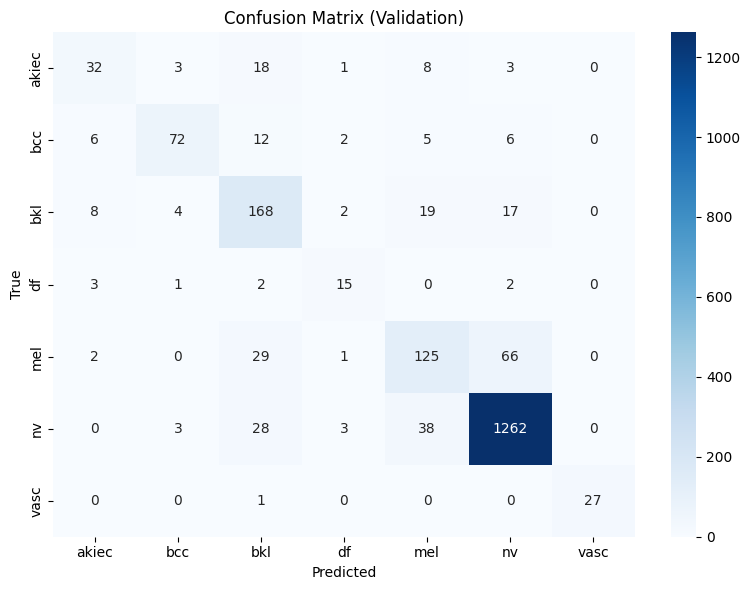

In [ ]:
# =========================
# Final evaluation on validation set
# =========================
print("\n📊 Final evaluation on validation set...\n")

y_true_all = []
y_pred_all = []

for (batch_x, batch_y) in val_ds:
    preds = model.predict(batch_x, verbose=0)
    y_true_all.append(batch_y.numpy())
    y_pred_all.append(np.argmax(preds, axis=1))

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

# 1. Overall accuracy
val_accuracy = (y_true_all == y_pred_all).mean()
print(f"Validation accuracy: {val_accuracy:.4f}")

# 2. Balanced accuracy (mean recall over classes)
bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)
print(f"Balanced accuracy (macro recall): {bal_acc:.4f}")

# 3. Classification report: precision, recall, F1 per class
print("\nClassification report (per class):\n")
print(classification_report(
    y_true_all,
    y_pred_all,
    target_names=class_names,
    digits=4
))

# 4. Confusion matrix (heatmap)
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Save final model
# =========================
model.save("final_multimodal_effnetb2.keras")
print("\n✅ Final model saved as final_multimodal_effnetb2.keras")
print("✅ Best checkpoint during training saved as best_model_b2.keras")


✅ Final model saved as final_multimodal_effnetb2.keras
✅ Best checkpoint during training saved as best_model_b2.keras


<H1>THE END